In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

# Display & style settings
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [21]:
master_raw = pd.read_csv(
    '../data/output/master_table.csv',
    parse_dates=['order_date', 'signup_date'],
    low_memory=False
)

# Global filter for all analyses/charts: exclude returned & cancelled orders
excluded_statuses = ['returned', 'cancelled']
status_norm = (
    master_raw['order_status']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)
master = master_raw[~status_norm.isin(excluded_statuses)].copy()

print(f"master_table loaded (raw): {len(master_raw):,} rows × {master_raw.shape[1]} columns")
print(f"master_table used (exclude returned/cancelled): {len(master):,} rows")
print(f"Thời gian: {master['order_date'].min().date()} → {master['order_date'].max().date()}")
master.head(3)

master_table loaded (raw): 714,669 rows × 53 columns
master_table used (exclude returned/cancelled): 608,962 rows
Thời gian: 2012-07-04 → 2022-12-31


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_item_id,line_revenue,order_date,...,promo_channel,min_order_value,stock_on_hand,fill_rate,sell_through_rate,stockout_flag,stockout_days,line_cogs,is_legacy,category_return_prob
0,1,2400,7,"1,138.22",0.00,NO_PROMO,NO_PROMO,1_2400,"7,967.54",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"7,376.59",1,0.06
2,3,396,3,"11,220.33",0.00,NO_PROMO,NO_PROMO,3_396,"33,660.99",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"30,273.04",1,0.06
3,4,635,5,"10,639.25",0.00,NO_PROMO,NO_PROMO,4_635,"53,196.25",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"46,027.15",1,0.06


In [43]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0 — Data Preparation
#   master_table: 1 row per order_item → aggregate to 1 row per order
#   Also parse product_name into brand / model_code / product_num
# ══════════════════════════════════════════════════════════════════════════

# ── Order-level aggregation ───────────────────────────────────────────────
order_level = (
    master.groupby('order_id', as_index=False)
    .agg(
        customer_id   = ('customer_id',  'first'),
        order_date    = ('order_date',   'first'),
        order_source  = ('order_source', 'first'),
        order_revenue = ('line_revenue', 'sum'),
    )
)

# Rank each customer's orders chronologically (1 = first ever order)
order_level = order_level.sort_values(['customer_id', 'order_date'])
order_level['order_rank'] = order_level.groupby('customer_id').cumcount() + 1
order_level['customer_type'] = np.where(
    order_level['order_rank'] == 1, 'New Customer', 'Returning Customer'
)

# ── Parse product_name → brand / model_code / product_num ────────────────
# Pattern: "VietMode RP-44" → brand="VietMode", model_code="RP", product_num="44"
def _parse_product(name):
    m = re.match(r'^(.+?)\s+([A-Z]+)-(\d+)$', str(name))
    return (m.group(1), m.group(2), m.group(3)) if m else (name, None, None)

_parsed = master['product_name'].apply(_parse_product)
master['brand']       = _parsed.apply(lambda t: t[0])
master['model_code']  = _parsed.apply(lambda t: t[1])
master['product_num'] = _parsed.apply(lambda t: t[2])

# ── Merge order_rank into master for item-level analyses ─────────────────
master_with_rank = master.merge(
    order_level[['order_id', 'order_rank', 'customer_type']],
    on='order_id', how='left'
)

# Subset: rows belonging to repeat orders (rank ≥ 2)
repeat_items = master_with_rank[master_with_rank['order_rank'] > 1].copy()

# ── Sanity checks ─────────────────────────────────────────────────────────
n_unique_orders   = len(order_level)
n_first           = (order_level['order_rank'] == 1).sum()
n_repeat          = (order_level['order_rank'] >  1).sum()
n_unique_custs    = order_level['customer_id'].nunique()
n_retained_custs  = order_level[order_level['order_rank'] > 1]['customer_id'].nunique()

print(f"Unique orders             : {n_unique_orders:,}")
print(f"First orders  (New)       : {n_first:,}")
print(f"Repeat orders (Returning) : {n_repeat:,}")
print(f"Unique customers          : {n_unique_custs:,}")
print(f"Retained customers (≥2 ord): {n_retained_custs:,}")
print(f"Overall retention rate     : {n_retained_custs / n_unique_custs * 100:.1f}%")
print(f"\nProduct name parse check  : {master['brand'].notna().sum():,} / {len(master):,} parsed OK")
print(f"Unique brands found       : {master['brand'].nunique()}")

Unique orders             : 551,341
First orders  (New)       : 86,643
Repeat orders (Returning) : 464,698
Unique customers          : 86,643
Retained customers (≥2 ord): 63,874
Overall retention rate     : 73.7%

Product name parse check  : 608,962 / 608,962 parsed OK
Unique brands found       : 14


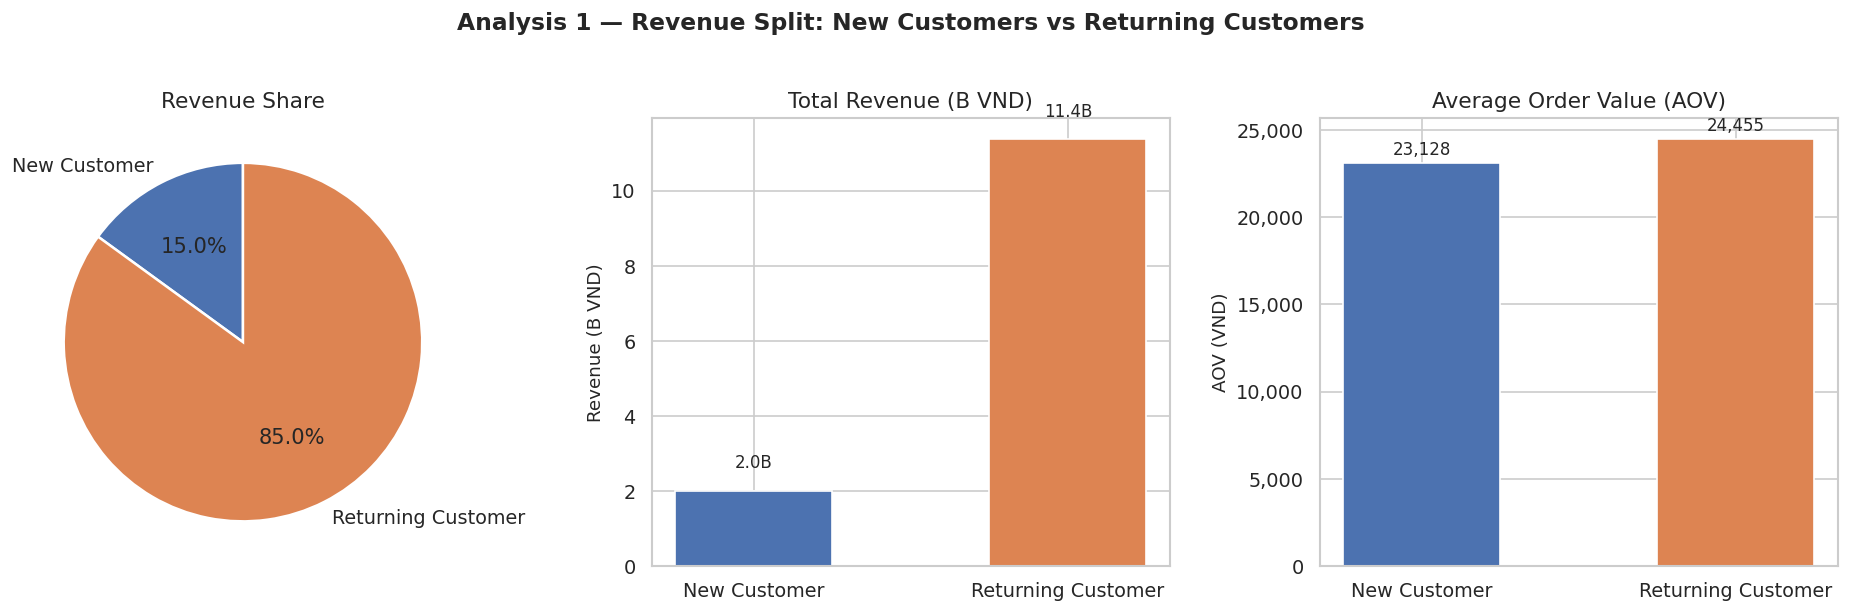


── Revenue Summary ──────────────────────────────────────────────────────
     customer_type     total_revenue  order_count  avg_order_value  revenue_share_pct
      New Customer  2,003,878,054.26        86643        23,127.99              14.99
Returning Customer 11,364,038,858.15       464698        24,454.68              85.01


In [44]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — Revenue Split: New Customers vs Returning Customers
# ══════════════════════════════════════════════════════════════════════════

rev_by_type = (
    order_level.groupby('customer_type')['order_revenue']
    .agg(total_revenue='sum', order_count='count', avg_order_value='mean')
    .reset_index()
)
rev_by_type['revenue_share_pct'] = (
    rev_by_type['total_revenue'] / rev_by_type['total_revenue'].sum() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analysis 1 — Revenue Split: New Customers vs Returning Customers',
             fontsize=14, fontweight='bold', y=1.02)

wedge_colors = ['#4C72B0', '#DD8452']

# (a) Revenue share — pie
axes[0].pie(
    rev_by_type['total_revenue'],
    labels=rev_by_type['customer_type'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Revenue Share')

# (b) Total revenue — bar
bars = axes[1].bar(
    rev_by_type['customer_type'],
    rev_by_type['total_revenue'] / 1e9,
    color=wedge_colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars, rev_by_type['total_revenue']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val/1e9:,.1f}B', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Total Revenue (B VND)')
axes[1].set_ylabel('Revenue (B VND)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (c) Average order value — bar
bars2 = axes[2].bar(
    rev_by_type['customer_type'],
    rev_by_type['avg_order_value'],
    color=wedge_colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars2, rev_by_type['avg_order_value']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + rev_by_type['avg_order_value'].max() * 0.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Average Order Value (AOV)')
axes[2].set_ylabel('AOV (VND)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Revenue Summary ──────────────────────────────────────────────────────")
print(rev_by_type[['customer_type', 'total_revenue', 'order_count',
                    'avg_order_value', 'revenue_share_pct']]
      .to_string(index=False))

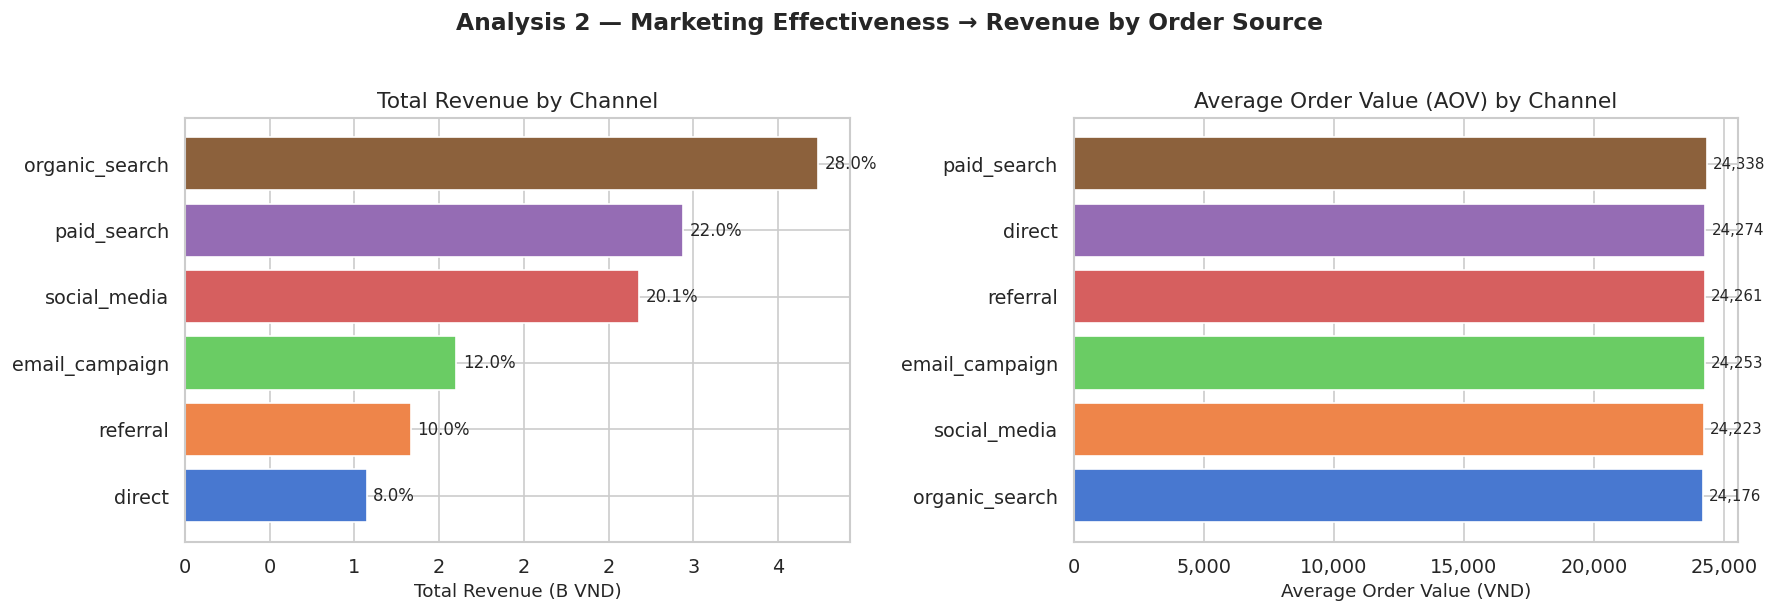


── Marketing → Revenue Summary ──────────────────────────────────────────
  order_source    total_revenue  order_count  avg_order_value  revenue_share_pct
organic_search 3,737,187,680.94       154584        24,175.77              27.96
   paid_search 2,941,163,580.31       120849        24,337.51              22.00
  social_media 2,680,839,897.18       110675        24,222.63              20.05
email_campaign 1,602,342,172.18        66068        24,252.92              11.99
      referral 1,333,019,645.69        54946        24,260.54               9.97
        direct 1,073,363,936.11        44219        24,273.82               8.03


In [45]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — Marketing Effectiveness → Revenue by Order Source
# ══════════════════════════════════════════════════════════════════════════

src_rev = (
    order_level.groupby('order_source')
    .agg(
        total_revenue   = ('order_revenue', 'sum'),
        order_count     = ('order_id',      'count'),
        avg_order_value = ('order_revenue', 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=True)   # ascending → largest bar at top in barh
)
src_rev['revenue_share_pct'] = (
    src_rev['total_revenue'] / src_rev['total_revenue'].sum() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analysis 2 — Marketing Effectiveness → Revenue by Order Source',
             fontsize=14, fontweight='bold', y=1.02)

palette = sns.color_palette('muted', len(src_rev))

# (a) Total revenue per source
bars = axes[0].barh(
    src_rev['order_source'],
    src_rev['total_revenue'] / 1e9,
    color=palette, edgecolor='white'
)
for bar, pct in zip(bars, src_rev['revenue_share_pct']):   # same order as bars
    axes[0].text(bar.get_width() + src_rev['total_revenue'].max() / 1e9 * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{pct:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('Total Revenue (B VND)')
axes[0].set_title('Total Revenue by Channel')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (b) Average order value per source — sorted descending by AOV (largest at top)
src_rev_aov = src_rev.sort_values('avg_order_value', ascending=True)
bars2 = axes[1].barh(
    src_rev_aov['order_source'],
    src_rev_aov['avg_order_value'],
    color=palette, edgecolor='white'
)
for bar, val in zip(bars2, src_rev_aov['avg_order_value']):
    axes[1].text(bar.get_width() + src_rev_aov['avg_order_value'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}', va='center', fontsize=9)
axes[1].set_xlabel('Average Order Value (VND)')
axes[1].set_title('Average Order Value (AOV) by Channel')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Marketing → Revenue Summary ──────────────────────────────────────────")
print(src_rev.sort_values('total_revenue', ascending=False)
      [['order_source', 'total_revenue', 'order_count',
        'avg_order_value', 'revenue_share_pct']]
      .to_string(index=False))

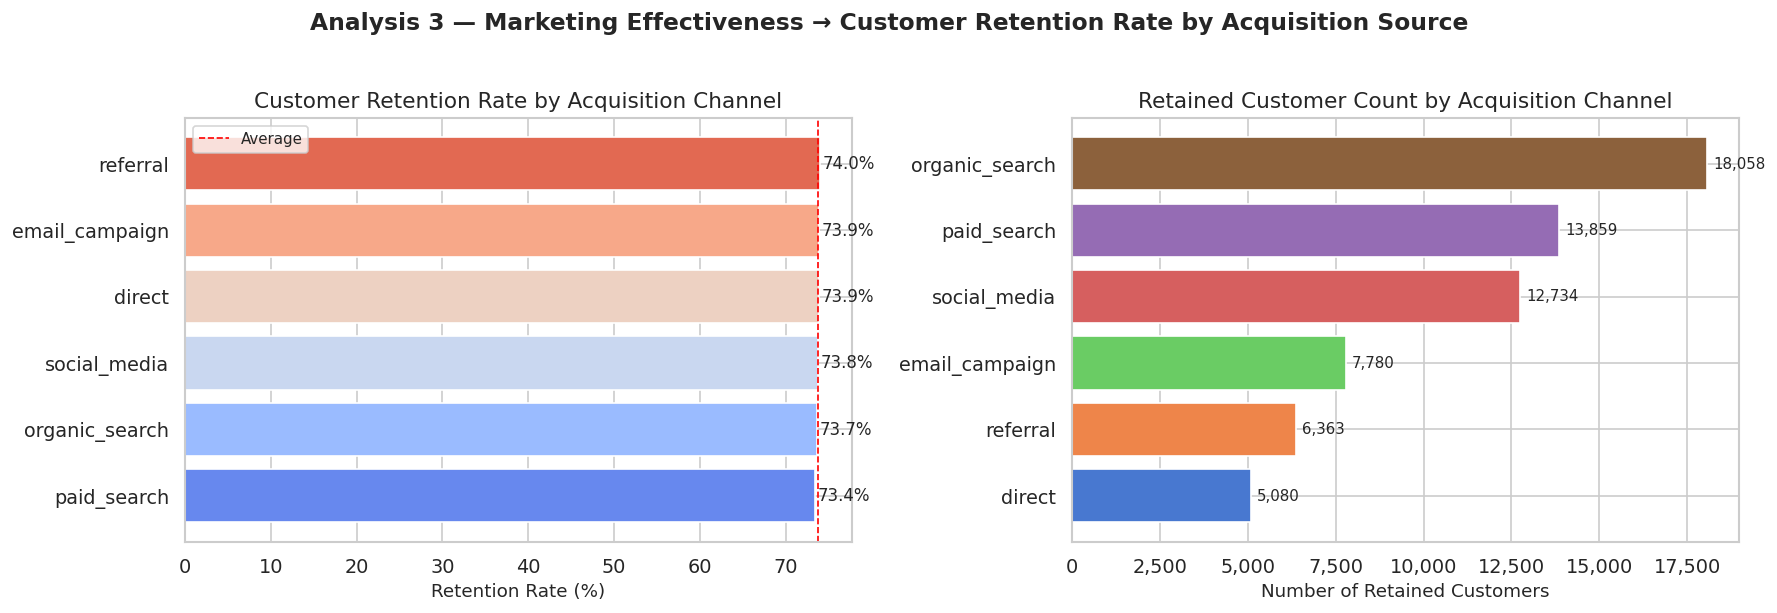


── Retention Rate by Acquisition Source ────────────────────────────────
acquisition_source  total_customers  retained_customers  retention_rate_pct
          referral             8598                6363               74.01
    email_campaign            10522                7780               73.94
            direct             6876                5080               73.88
      social_media            17253               12734               73.81
    organic_search            24516               18058               73.66
       paid_search            18878               13859               73.41


In [46]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 3 — Marketing Effectiveness → Retention Rate by Acquisition Source
#
# Logic:
#   - The order_source of a customer's FIRST order is their "acquisition channel"
#   - A customer is "retained" if they placed at least one subsequent order
#   - Retention rate = retained customers / total customers acquired per channel
# ══════════════════════════════════════════════════════════════════════════

# One row per customer: acquisition source = order_source of their rank-1 order
first_orders = (
    order_level[order_level['order_rank'] == 1]
    [['customer_id', 'order_source']]
    .rename(columns={'order_source': 'acquisition_source'})
)

# Total number of orders each customer ever placed
cust_order_count = (
    order_level.groupby('customer_id', as_index=False)['order_id']
    .count()
    .rename(columns={'order_id': 'total_orders'})
)

first_orders = first_orders.merge(cust_order_count, on='customer_id')
first_orders['is_retained'] = first_orders['total_orders'] > 1

retention_by_src = (
    first_orders.groupby('acquisition_source', as_index=False)
    .agg(
        total_customers    = ('customer_id', 'count'),
        retained_customers = ('is_retained', 'sum'),
    )
)
retention_by_src['retention_rate_pct'] = (
    retention_by_src['retained_customers'] / retention_by_src['total_customers'] * 100
)
# Sort ascending so highest retention rate appears at top in barh
retention_by_src = retention_by_src.sort_values('retention_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analysis 3 — Marketing Effectiveness → Customer Retention Rate by Acquisition Source',
             fontsize=14, fontweight='bold', y=1.02)

pal3 = sns.color_palette('coolwarm', len(retention_by_src))

# (a) Retention rate % — largest at top
bars = axes[0].barh(
    retention_by_src['acquisition_source'],
    retention_by_src['retention_rate_pct'],
    color=pal3, edgecolor='white'
)
for bar, val in zip(bars, retention_by_src['retention_rate_pct']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].set_title('Customer Retention Rate by Acquisition Channel')
axes[0].axvline(retention_by_src['retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute count of retained customers — sorted largest at top
ret_abs = retention_by_src.sort_values('retained_customers', ascending=True)
bars2 = axes[1].barh(
    ret_abs['acquisition_source'],
    ret_abs['retained_customers'],
    color=sns.color_palette('muted', len(ret_abs)), edgecolor='white'
)
for bar, val in zip(bars2, ret_abs['retained_customers']):
    axes[1].text(bar.get_width() + ret_abs['retained_customers'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Retained Customers')
axes[1].set_title('Retained Customer Count by Acquisition Channel')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Retention Rate by Acquisition Source ────────────────────────────────")
print(retention_by_src.sort_values('retention_rate_pct', ascending=False)
      [['acquisition_source', 'total_customers', 'retained_customers', 'retention_rate_pct']]
      .to_string(index=False))

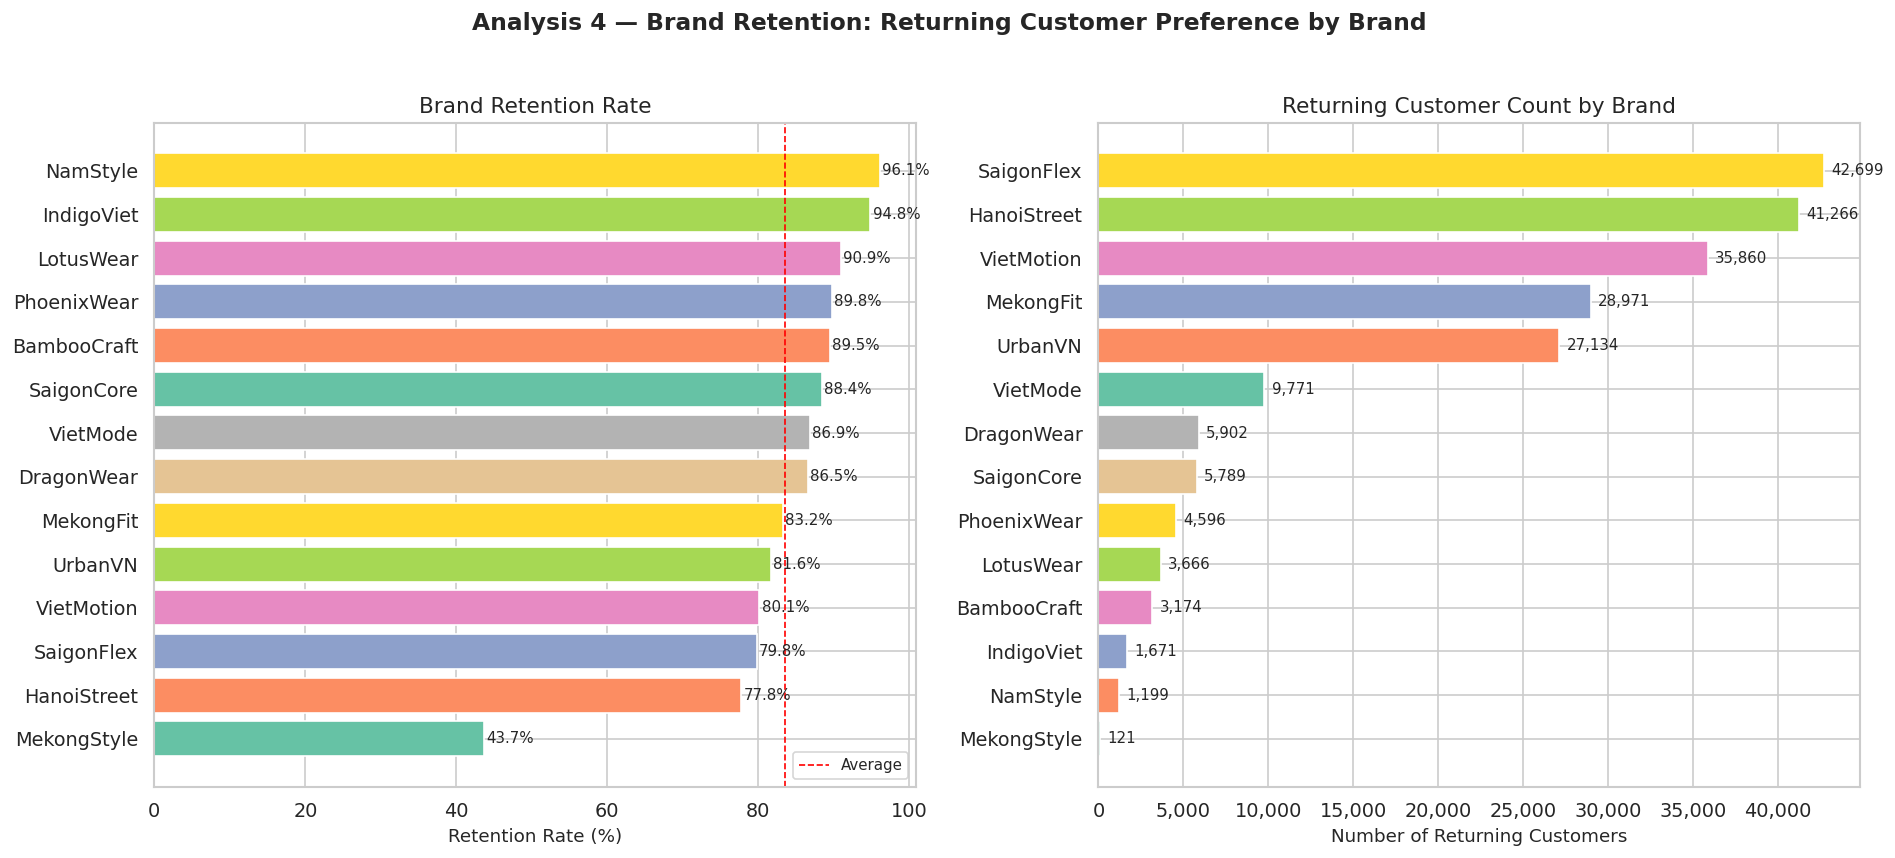


── Brand Retention Summary ──────────────────────────────────────────────
      brand  total_customers  repeat_customers  repeat_orders  brand_retention_rate_pct
   NamStyle             1248              1199           1271                     96.07
 IndigoViet             1762              1671           1714                     94.84
  LotusWear             4031              3666           4157                     90.95
PhoenixWear             5119              4596           5095                     89.78
BambooCraft             3546              3174           3428                     89.51
 SaigonCore             6548              5789           7302                     88.41
   VietMode            11249              9771          14274                     86.86
 DragonWear             6820              5902           7110                     86.54
  MekongFit            34805             28971          54016                     83.24
    UrbanVN            33235             2713

In [47]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 4 — Brand Retention: Which Brand Do Returning Customers Prefer?
#
# Metric: brand retention rate =
#   customers who purchased brand B in a repeat order (rank ≥ 2)
#   ÷ all customers who ever purchased brand B (any rank)
# ══════════════════════════════════════════════════════════════════════════

brand_repeat = (
    repeat_items.groupby('brand', as_index=False)
    .agg(
        repeat_orders    = ('order_id',    'nunique'),
        repeat_customers = ('customer_id', 'nunique'),
    )
)

brand_total_cust = (
    master_with_rank.groupby('brand', as_index=False)['customer_id']
    .nunique()
    .rename(columns={'customer_id': 'total_customers'})
)
brand_repeat = brand_repeat.merge(brand_total_cust, on='brand')
brand_repeat['brand_retention_rate_pct'] = (
    brand_repeat['repeat_customers'] / brand_repeat['total_customers'] * 100
)
# Sort ascending so highest rate appears at top in barh
brand_repeat = brand_repeat.sort_values('brand_retention_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analysis 4 — Brand Retention: Returning Customer Preference by Brand',
             fontsize=14, fontweight='bold', y=1.02)

pal4 = sns.color_palette('Set2', len(brand_repeat))

# (a) Retention rate by brand — highest at top
bars = axes[0].barh(
    brand_repeat['brand'],
    brand_repeat['brand_retention_rate_pct'],
    color=pal4, edgecolor='white'
)
for bar, val in zip(bars, brand_repeat['brand_retention_rate_pct']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].set_title('Brand Retention Rate')
axes[0].axvline(brand_repeat['brand_retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute repeat customers by brand — highest at top
brand_abs = brand_repeat.sort_values('repeat_customers', ascending=True)
bars2 = axes[1].barh(
    brand_abs['brand'],
    brand_abs['repeat_customers'],
    color=pal4, edgecolor='white'
)
for bar, val in zip(bars2, brand_abs['repeat_customers']):
    axes[1].text(bar.get_width() + brand_abs['repeat_customers'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Returning Customers')
axes[1].set_title('Returning Customer Count by Brand')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Brand Retention Summary ──────────────────────────────────────────────")
print(brand_repeat.sort_values('brand_retention_rate_pct', ascending=False)
      [['brand', 'total_customers', 'repeat_customers',
        'repeat_orders', 'brand_retention_rate_pct']]
      .to_string(index=False))

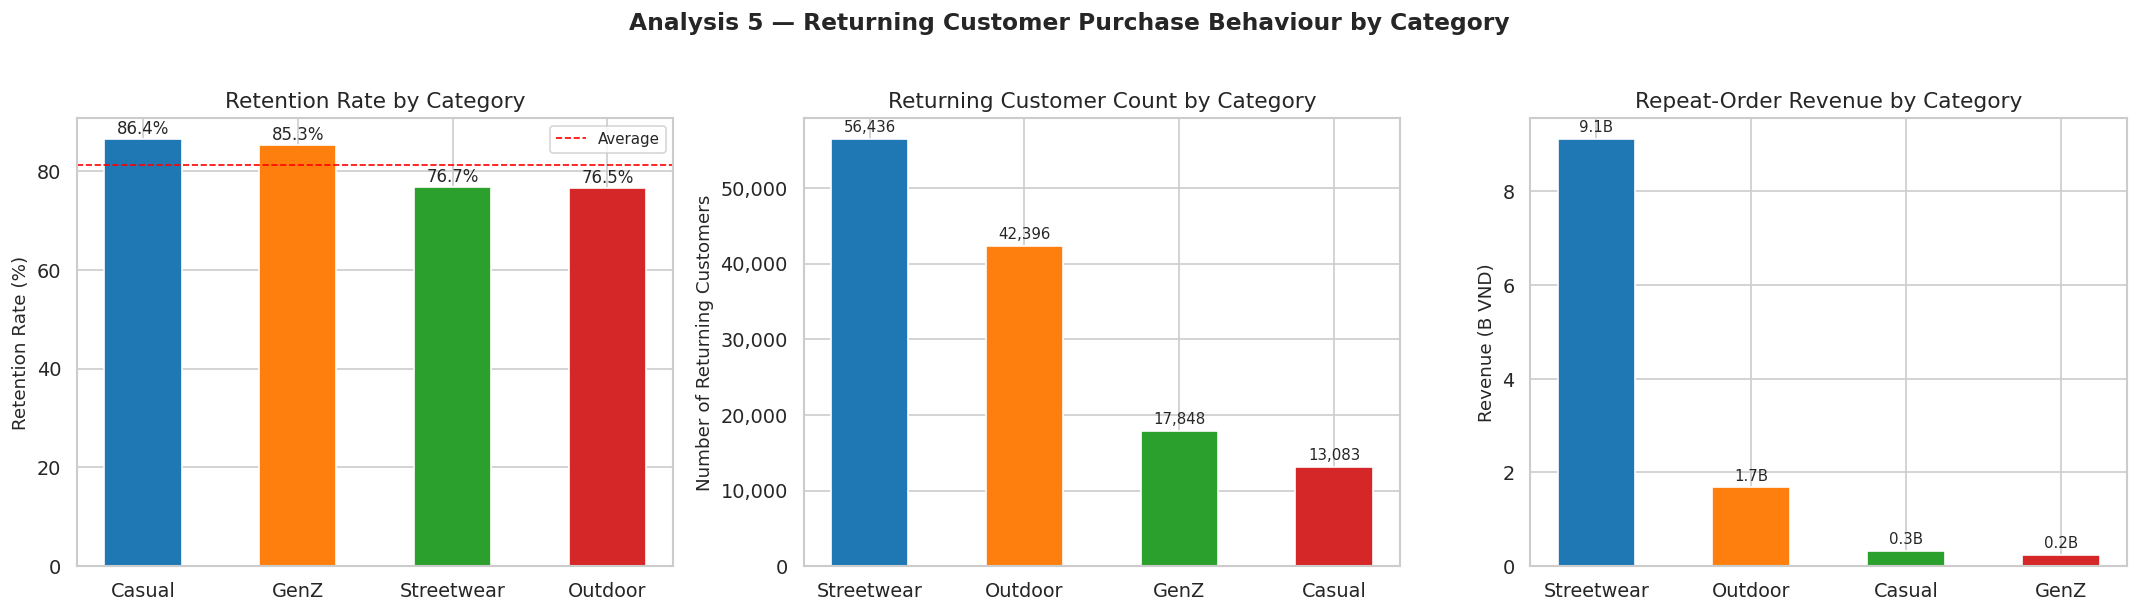


── Category Retention Summary ───────────────────────────────────────────
  category  total_customers  repeat_customers  repeat_orders   repeat_revenue  cat_retention_rate_pct
    Casual            15141             13083          17704   332,504,592.23                   86.41
      GenZ            20930             17848          27287   245,474,006.73                   85.27
Streetwear            73556             56436         281990 9,106,843,406.11                   76.73
   Outdoor            55387             42396         140643 1,679,216,853.08                   76.55


In [48]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 5 — Which Categories Do Returning Customers Buy Most?
# ══════════════════════════════════════════════════════════════════════════

cat_repeat = (
    repeat_items.groupby('category', as_index=False)
    .agg(
        repeat_orders    = ('order_id',    'nunique'),
        repeat_customers = ('customer_id', 'nunique'),
        repeat_revenue   = ('line_revenue', 'sum'),
    )
)

cat_total_cust = (
    master_with_rank.groupby('category', as_index=False)['customer_id']
    .nunique()
    .rename(columns={'customer_id': 'total_customers'})
)
cat_repeat = cat_repeat.merge(cat_total_cust, on='category')
# Retention rate = customers who bought category C in a repeat order /
#                  all customers who ever bought category C
cat_repeat['cat_retention_rate_pct'] = (
    cat_repeat['repeat_customers'] / cat_repeat['total_customers'] * 100
)
cat_repeat = cat_repeat.sort_values('cat_retention_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analysis 5 — Returning Customer Purchase Behaviour by Category',
             fontsize=14, fontweight='bold', y=1.02)

pal5 = sns.color_palette('tab10', len(cat_repeat))

# (a) Retention rate by category
bars = axes[0].bar(
    cat_repeat['category'],
    cat_repeat['cat_retention_rate_pct'],
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars, cat_repeat['cat_retention_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Retention Rate (%)')
axes[0].set_title('Retention Rate by Category')
axes[0].axhline(cat_repeat['cat_retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute repeat customers count
cat_abs = cat_repeat.sort_values('repeat_customers', ascending=False)
bars2 = axes[1].bar(
    cat_abs['category'],
    cat_abs['repeat_customers'],
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars2, cat_abs['repeat_customers']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cat_abs['repeat_customers'].max() * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Number of Returning Customers')
axes[1].set_title('Returning Customer Count by Category')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (c) Revenue from repeat orders by category
cat_rev = cat_repeat.sort_values('repeat_revenue', ascending=False)
bars3 = axes[2].bar(
    cat_rev['category'],
    cat_rev['repeat_revenue'] / 1e9,
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars3, cat_rev['repeat_revenue']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cat_rev['repeat_revenue'].max() / 1e9 * 0.01,
                 f'{val/1e9:.1f}B', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('Revenue (B VND)')
axes[2].set_title('Repeat-Order Revenue by Category')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Category Retention Summary ───────────────────────────────────────────")
print(cat_repeat[['category', 'total_customers', 'repeat_customers',
                   'repeat_orders', 'repeat_revenue', 'cat_retention_rate_pct']]
      .sort_values('cat_retention_rate_pct', ascending=False)
      .to_string(index=False))

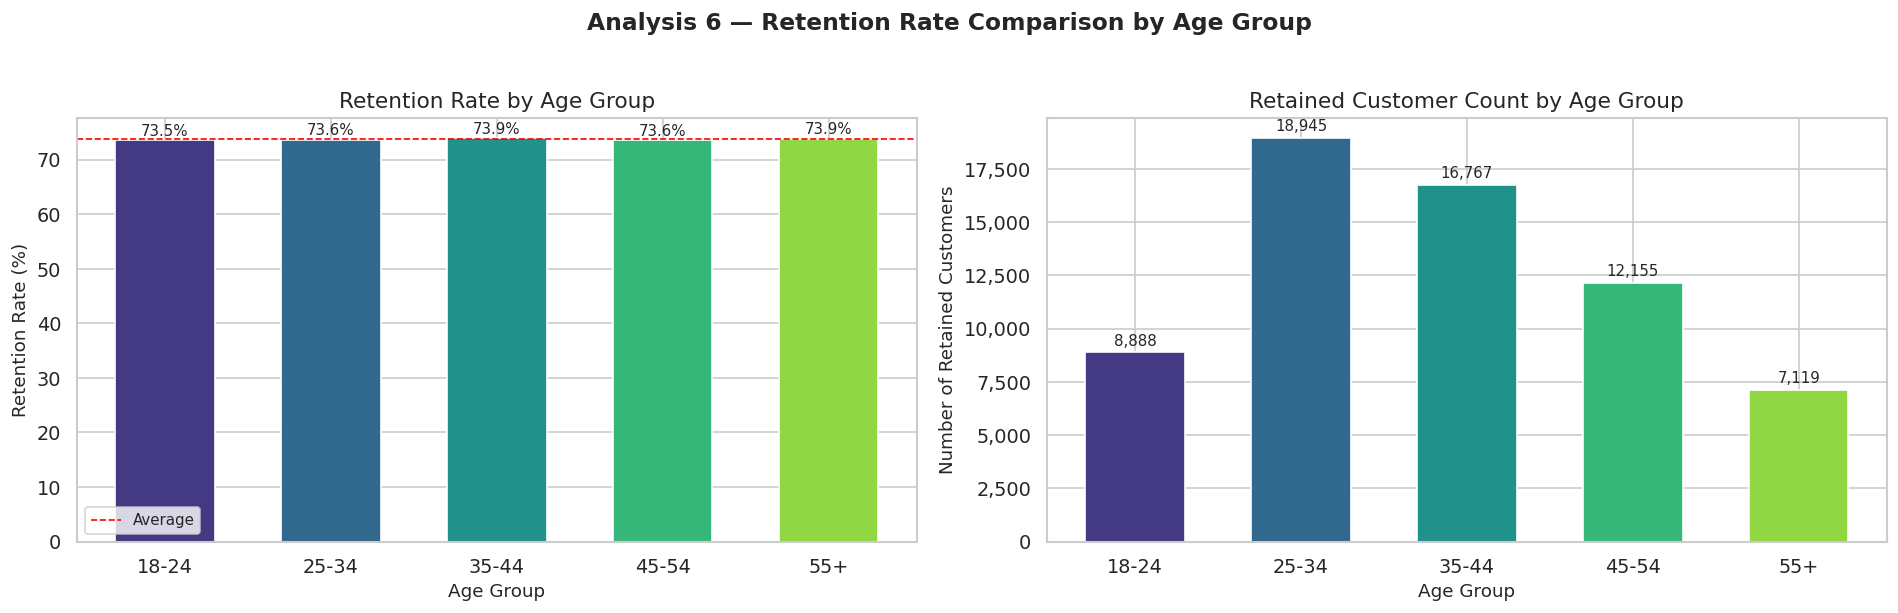


── Retention Summary by Age Group ────────────────────────────────────────
age_group  total_customers  retained_customers  retention_rate_pct
    35-44            22680               16767               73.93
      55+             9637                7119               73.87
    25-34            25725               18945               73.64
    45-54            16514               12155               73.60
    18-24            12087                8888               73.53


In [49]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 6 — Compare Retention Rate by Age Group
#
# Logic:
#   - One row per customer
#   - Retained customer = total_orders > 1
#   - age_group per customer is taken as the most frequent value in master
# ══════════════════════════════════════════════════════════════════════════

# Customer-level order count
cust_orders = (
    order_level.groupby('customer_id', as_index=False)['order_id']
    .count()
    .rename(columns={'order_id': 'total_orders'})
)

# Resolve age_group per customer (robust in case of inconsistent records)
cust_age = (
    master[['customer_id', 'age_group']]
    .dropna(subset=['customer_id'])
    .groupby('customer_id', as_index=False)['age_group']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

cust_profile = cust_orders.merge(cust_age, on='customer_id', how='left')
cust_profile['age_group'] = cust_profile['age_group'].fillna('Unknown')
cust_profile['is_retained'] = cust_profile['total_orders'] > 1

retention_by_age = (
    cust_profile.groupby('age_group', as_index=False)
    .agg(
        total_customers=('customer_id', 'count'),
        retained_customers=('is_retained', 'sum'),
    )
)
retention_by_age['retention_rate_pct'] = (
    retention_by_age['retained_customers'] / retention_by_age['total_customers'] * 100
)

# Sort age groups by leading numeric value so bars follow age progression
age_start = pd.to_numeric(
    retention_by_age['age_group'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)
retention_by_age = (
    retention_by_age.assign(_sort_key=age_start.fillna(999))
    .sort_values('_sort_key')
    .drop(columns='_sort_key')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Analysis 6 — Retention Rate Comparison by Age Group',
             fontsize=14, fontweight='bold', y=1.02)

pal6 = sns.color_palette('viridis', len(retention_by_age))

# (a) Retention rate (%) by age group
bars = axes[0].bar(
    retention_by_age['age_group'],
    retention_by_age['retention_rate_pct'],
    color=pal6, edgecolor='white', width=0.6
)
for bar, val in zip(bars, retention_by_age['retention_rate_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_title('Retention Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Retention Rate (%)')
axes[0].axhline(retention_by_age['retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Retained customer count by age group
bars2 = axes[1].bar(
    retention_by_age['age_group'],
    retention_by_age['retained_customers'],
    color=pal6, edgecolor='white', width=0.6
)
for bar, val in zip(bars2, retention_by_age['retained_customers']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + retention_by_age['retained_customers'].max() * 0.01,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9
    )
axes[1].set_title('Retained Customer Count by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Retained Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Retention Summary by Age Group ────────────────────────────────────────")
print(retention_by_age.sort_values('retention_rate_pct', ascending=False)
      [['age_group', 'total_customers', 'retained_customers', 'retention_rate_pct']]
      .to_string(index=False))

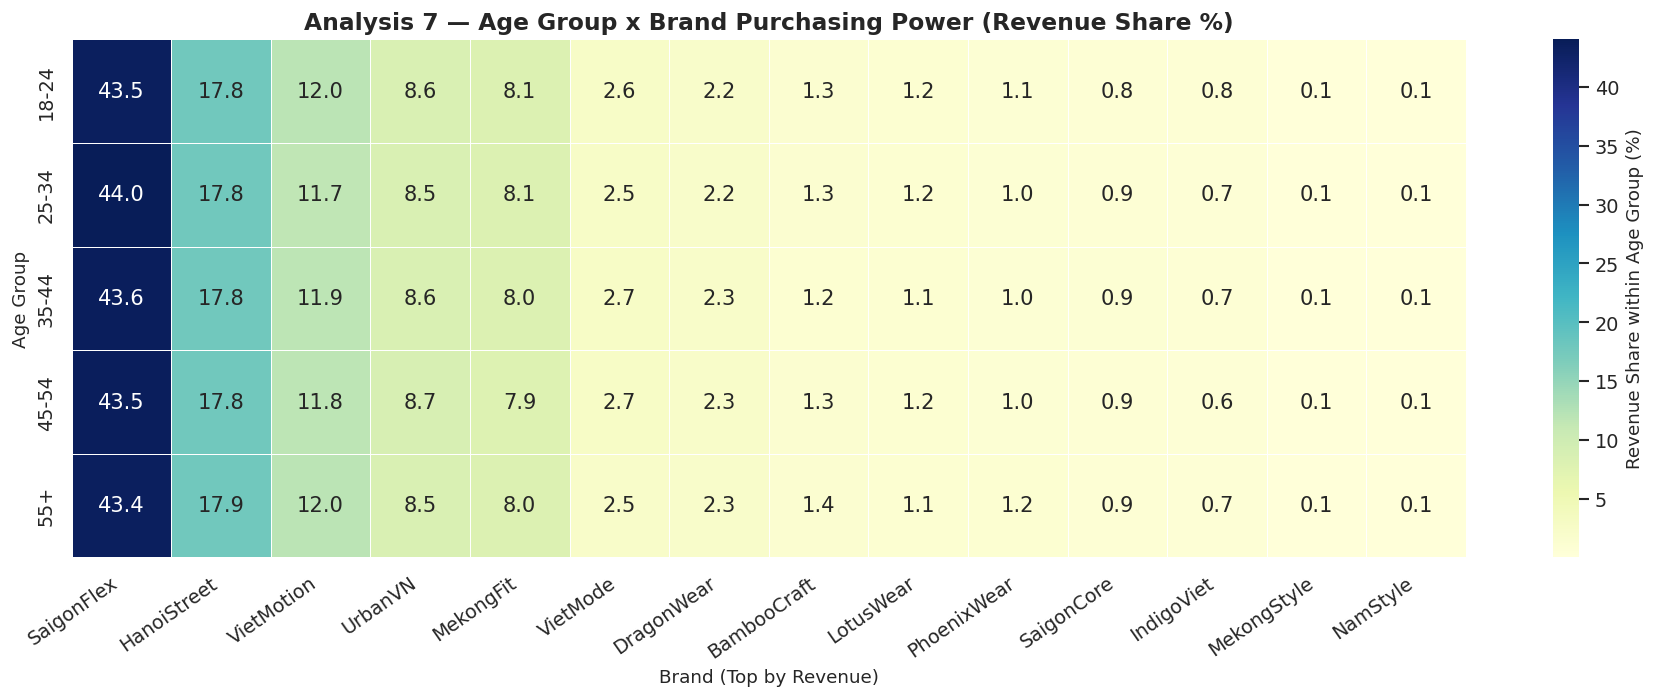


── Age Group x Brand Summary (Top Brand per Age Group) ─────────────────────
age_group  top_brand  top_brand_share_pct
    18-24 SaigonFlex                43.46
    25-34 SaigonFlex                44.01
    35-44 SaigonFlex                43.64
    45-54 SaigonFlex                43.52
      55+ SaigonFlex                43.43


In [50]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 7 — Age Group x Brand Purchasing Power (Revenue Share Heatmap)
#
# Metric:
#   For each age_group, compute revenue share (%) contributed by each brand.
#   This highlights brand preference structure inside each age segment.
# ══════════════════════════════════════════════════════════════════════════

age_brand = master[['age_group', 'brand', 'line_revenue']].copy()
age_brand['age_group'] = age_brand['age_group'].fillna('Unknown')
age_brand['brand'] = age_brand['brand'].fillna('Unknown')

# Limit to top brands by overall revenue for readability
# top_n_brands = 12
top_brands = (
    age_brand.groupby('brand', as_index=False)['line_revenue']
    .sum()
    .sort_values('line_revenue', ascending=False)['brand']
    .tolist()
)

age_brand_top = age_brand[age_brand['brand'].isin(top_brands)].copy()

rev_matrix = age_brand_top.pivot_table(
    index='age_group',
    columns='brand',
    values='line_revenue',
    aggfunc='sum',
    fill_value=0
)

# Keep age progression order: 18-24, 25-34, ..., Unknown
age_order_key = pd.to_numeric(
    rev_matrix.index.to_series().astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)
row_order = age_order_key.fillna(999).sort_values().index
rev_matrix = rev_matrix.reindex(row_order)

# Keep brand order by total revenue
rev_matrix = rev_matrix.reindex(columns=top_brands, fill_value=0)

# Convert to within-age-group percentage share
share_matrix = rev_matrix.div(rev_matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

plt.figure(figsize=(max(12, len(top_brands) * 1.1), max(5, len(share_matrix.index) * 0.7 + 2.5)))
sns.heatmap(
    share_matrix,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    cbar_kws={'label': 'Revenue Share within Age Group (%)'}
)
plt.title('Analysis 7 — Age Group x Brand Purchasing Power (Revenue Share %)', fontsize=14, fontweight='bold')
plt.xlabel('Brand (Top by Revenue)')
plt.ylabel('Age Group')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Quick summary: top-preferred brand by each age group
top_brand_by_age = pd.DataFrame({
    'top_brand': share_matrix.idxmax(axis=1),
    'top_brand_share_pct': share_matrix.max(axis=1)
}).reset_index()

print("\n── Age Group x Brand Summary (Top Brand per Age Group) ─────────────────────")
print(top_brand_by_age.to_string(index=False))

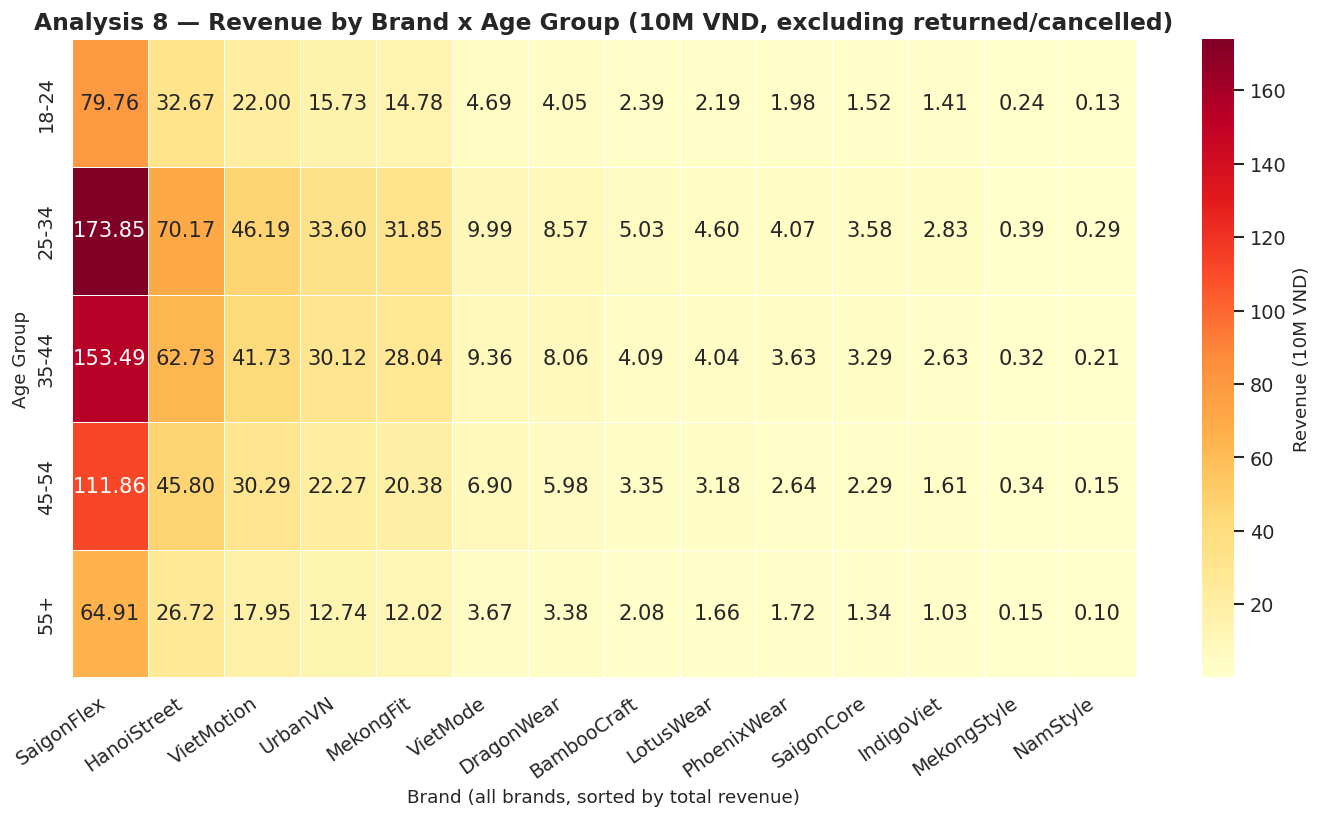


── Analysis 8 Summary ────────────────────────────────────────────────────
Valid items used: 608,962
Brands included : 14
Total revenue (B VND, valid only): 1,336.79


In [51]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 8 — Revenue by Brand x Age Group (B VND, Exclude Returned/Cancelled)
#
# Rule:
#   - Keep only items in orders with order_status NOT IN {'returned', 'cancelled'}
#   - Metric is absolute revenue (shown in B VND), NOT percentage share
# ══════════════════════════════════════════════════════════════════════════

valid_items = master[~master['order_status']
                  .fillna('')
                  .astype(str)
                  .str.strip()
                  .str.lower()
                  .isin(['returned', 'cancelled'])].copy()

# Safety fallback if notebook is run from this cell only
if 'brand' not in valid_items.columns:
    def _parse_brand_only(name):
        m = re.match(r'^(.+?)\s+([A-Z]+)-(\d+)$', str(name))
        return m.group(1) if m else str(name)
    valid_items['brand'] = valid_items['product_name'].apply(_parse_brand_only)

age_brand_vnd = valid_items[['age_group', 'brand', 'line_revenue']].copy()
age_brand_vnd['age_group'] = age_brand_vnd['age_group'].fillna('Unknown')
age_brand_vnd['brand'] = age_brand_vnd['brand'].fillna('Unknown')

# Brand order by total revenue (descending)
brand_order = (
    age_brand_vnd.groupby('brand')['line_revenue']
    .sum()
    .sort_values(ascending=False)
    .index
)

rev_matrix_vnd = age_brand_vnd.pivot_table(
    index='age_group',
    columns='brand',
    values='line_revenue',
    aggfunc='sum',
    fill_value=0
)

# Keep age progression order: 18-24, 25-34, ..., Unknown
age_order_key_vnd = pd.to_numeric(
    rev_matrix_vnd.index.to_series().astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)
age_order_vnd = age_order_key_vnd.fillna(999).sort_values().index
rev_matrix_vnd = rev_matrix_vnd.reindex(index=age_order_vnd, columns=brand_order, fill_value=0)

# Scale to billions (1B VND) for readability
rev_matrix_b = rev_matrix_vnd / 1e7

annotate_cells = rev_matrix_b.shape[1] <= 15
fig_w = max(12, min(36, rev_matrix_b.shape[1] * 0.65))
fig_h = max(5, rev_matrix_b.shape[0] * 0.9 + 2.5)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    rev_matrix_b,
    cmap='YlOrRd',
    annot=annotate_cells,
    fmt='.2f',
    linewidths=0.35,
    cbar_kws={'label': 'Revenue (10M VND)'}
)
plt.title('Analysis 8 — Revenue by Brand x Age Group (10M VND, excluding returned/cancelled)',
          fontsize=14, fontweight='bold')
plt.xlabel('Brand (all brands, sorted by total revenue)')
plt.ylabel('Age Group')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\n── Analysis 8 Summary ────────────────────────────────────────────────────')
print(f'Valid items used: {len(valid_items):,}')
print(f'Brands included : {rev_matrix_vnd.shape[1]:,}')
print(f'Total revenue (B VND, valid only): {rev_matrix_b.to_numpy().sum():,.2f}')

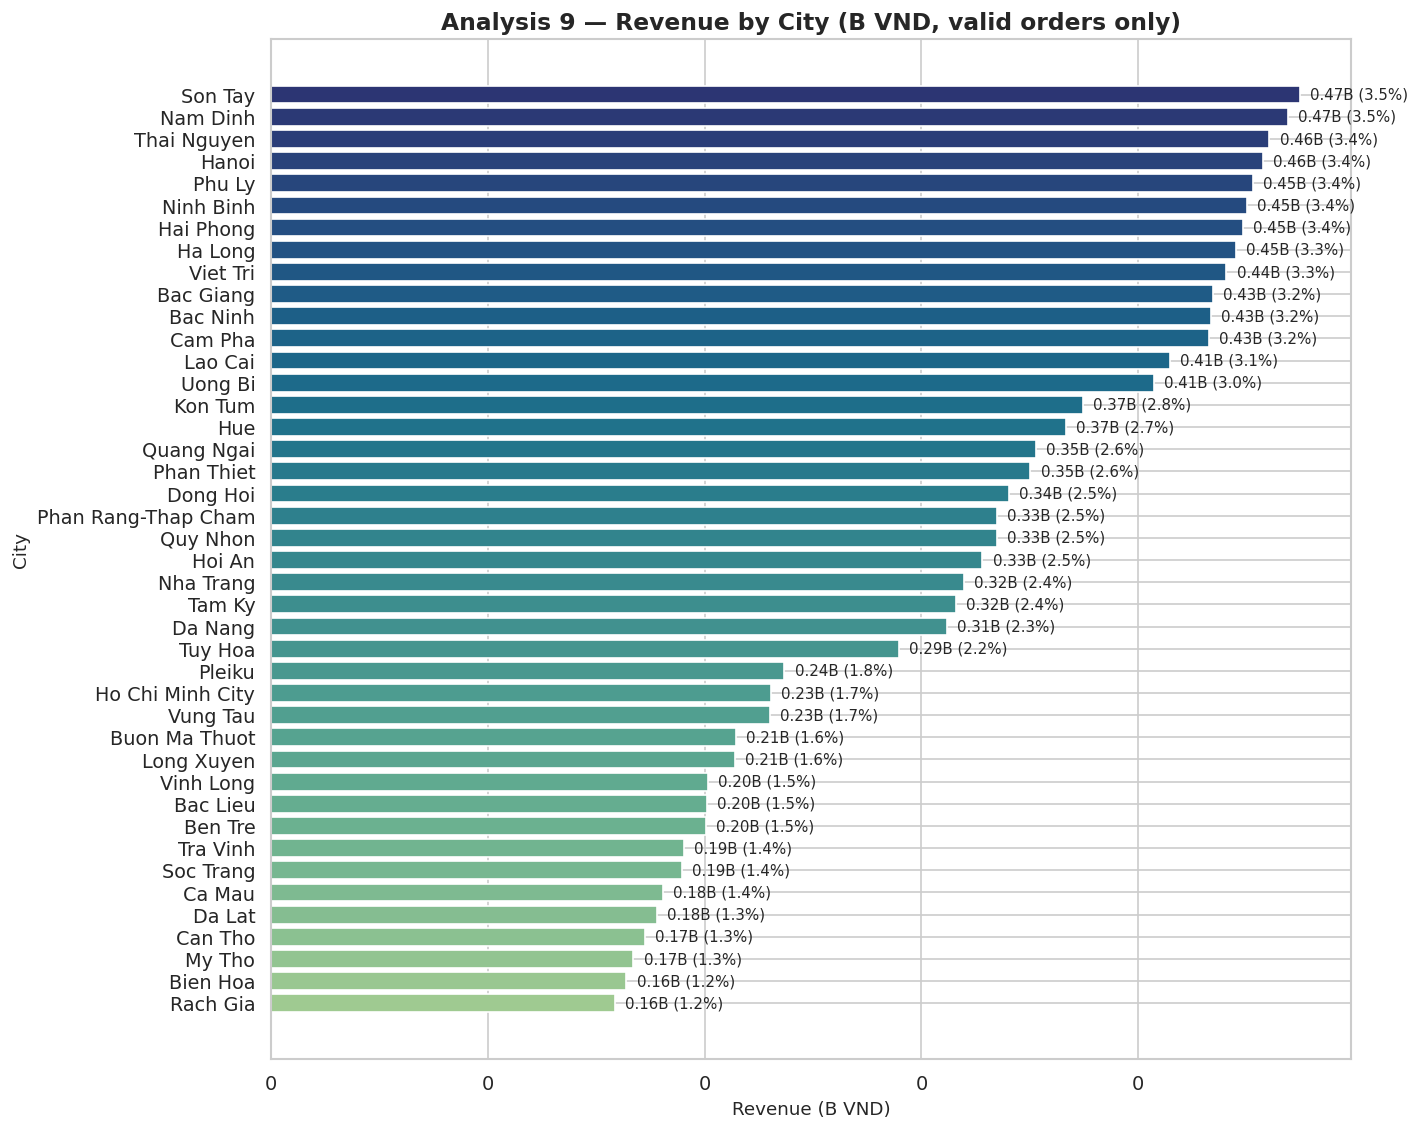


── City Revenue Summary──────────────────────────────────────────
               city  total_revenue  revenue_b_vnd  item_count  revenue_share_pct
            Son Tay 474,414,270.39           0.47       20838               3.55
           Nam Dinh 469,055,548.91           0.47       20246               3.51
        Thai Nguyen 460,516,665.13           0.46       20349               3.44
              Hanoi 457,425,887.58           0.46       20159               3.42
             Phu Ly 452,736,006.59           0.45       19796               3.39
          Ninh Binh 450,110,577.98           0.45       19548               3.37
          Hai Phong 448,242,684.98           0.45       19673               3.35
            Ha Long 445,043,076.10           0.45       19517               3.33
           Viet Tri 440,688,238.24           0.44       19283               3.30
          Bac Giang 434,417,798.25           0.43       19327               3.25
           Bac Ninh 433,374,891.33        

In [52]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 9 — Revenue by City (B VND)
#
# Note:
#   master is already globally filtered in Cell 2
#   (order_status excludes returned/cancelled)
# ══════════════════════════════════════════════════════════════════════════

city_rev = (
    master[['city', 'line_revenue']]
    .assign(city=lambda d: d['city'].fillna('Unknown').astype(str).str.strip())
    .assign(city=lambda d: d['city'].replace('', 'Unknown'))
    .groupby('city', as_index=False)
    .agg(
        total_revenue=('line_revenue', 'sum'),
        item_count=('line_revenue', 'size'),
    )
)

city_rev['revenue_b_vnd'] = city_rev['total_revenue'] / 1e9
city_rev = city_rev.sort_values('total_revenue', ascending=False)
city_rev['revenue_share_pct'] = city_rev['total_revenue'] / city_rev['total_revenue'].sum() * 100

# top_n_cities = min(20, len(city_rev))
city_top = city_rev.sort_values('revenue_b_vnd', ascending=True)

plt.figure(figsize=(12, max(5, top_n_cities * 0.38 + 2)))
bars = plt.barh(
    city_top['city'],
    city_top['revenue_b_vnd'],
    color=sns.color_palette('crest', len(city_top)),
    edgecolor='white'
)
for bar, val, pct in zip(bars, city_top['revenue_b_vnd'], city_top['revenue_share_pct']):
    plt.text(
        bar.get_width() + city_top['revenue_b_vnd'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.2f}B ({pct:.1f}%)',
        va='center',
        fontsize=9
    )

plt.title('Analysis 9 — Revenue by City (B VND, valid orders only)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (B VND)')
plt.ylabel('City')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n── City Revenue Summary──────────────────────────────────────────')
print(city_rev[['city', 'total_revenue', 'revenue_b_vnd', 'item_count', 'revenue_share_pct']]
      .to_string(index=False))

In [53]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 10 — City List + Order Count + Returned Order Count (Order-level)
#
# Note:
#   This analysis uses master_raw to include all statuses,
#   then aggregates to 1 row per order_id before city-level counting.
# ══════════════════════════════════════════════════════════════════════════

order_city_status = (
    master_raw[['order_id', 'city', 'order_status']]
    .assign(
        city=lambda d: d['city'].fillna('Unknown').astype(str).str.strip(),
        order_status_norm=lambda d: d['order_status'].fillna('').astype(str).str.strip().str.lower()
    )
    .assign(city=lambda d: d['city'].replace('', 'Unknown'))
    .groupby('order_id', as_index=False)
    .agg(
        city=('city', 'first'),
        order_status_norm=('order_status_norm', 'first')
    )
)

all_cities = sorted(order_city_status['city'].dropna().unique().tolist())

print('\n── All Cities ────────────────────────────────────────────────────────────')
print(f'Total unique cities: {len(all_cities):,}')
print(' | '.join(all_cities))

city_order_stats = (
    order_city_status.groupby('city', as_index=False)
    .agg(
        total_orders=('order_id', 'nunique'),
        returned_orders=('order_status_norm', lambda s: (s == 'returned').sum())
    )
)

city_order_stats['return_rate_pct'] = (
    city_order_stats['returned_orders'] / city_order_stats['total_orders'] * 100
)
city_order_stats = city_order_stats.sort_values(
    ['total_orders', 'returned_orders'],
    ascending=[False, False]
)

print('\n── City Order Statistics ─────────────────────────────────────────────────')
print(city_order_stats.to_string(index=False))


── All Cities ────────────────────────────────────────────────────────────
Total unique cities: 42
Bac Giang | Bac Lieu | Bac Ninh | Ben Tre | Bien Hoa | Buon Ma Thuot | Ca Mau | Cam Pha | Can Tho | Da Lat | Da Nang | Dong Hoi | Ha Long | Hai Phong | Hanoi | Ho Chi Minh City | Hoi An | Hue | Kon Tum | Lao Cai | Long Xuyen | My Tho | Nam Dinh | Nha Trang | Ninh Binh | Phan Rang-Thap Cham | Phan Thiet | Phu Ly | Pleiku | Quang Ngai | Quy Nhon | Rach Gia | Soc Trang | Son Tay | Tam Ky | Thai Nguyen | Tra Vinh | Tuy Hoa | Uong Bi | Viet Tri | Vinh Long | Vung Tau

── City Order Statistics ─────────────────────────────────────────────────
               city  total_orders  returned_orders  return_rate_pct
            Son Tay         22473             1254             5.58
        Thai Nguyen         21931             1248             5.69
           Nam Dinh         21764             1203             5.53
              Hanoi         21576             1167             5.41
             Phu 